In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import entropy


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


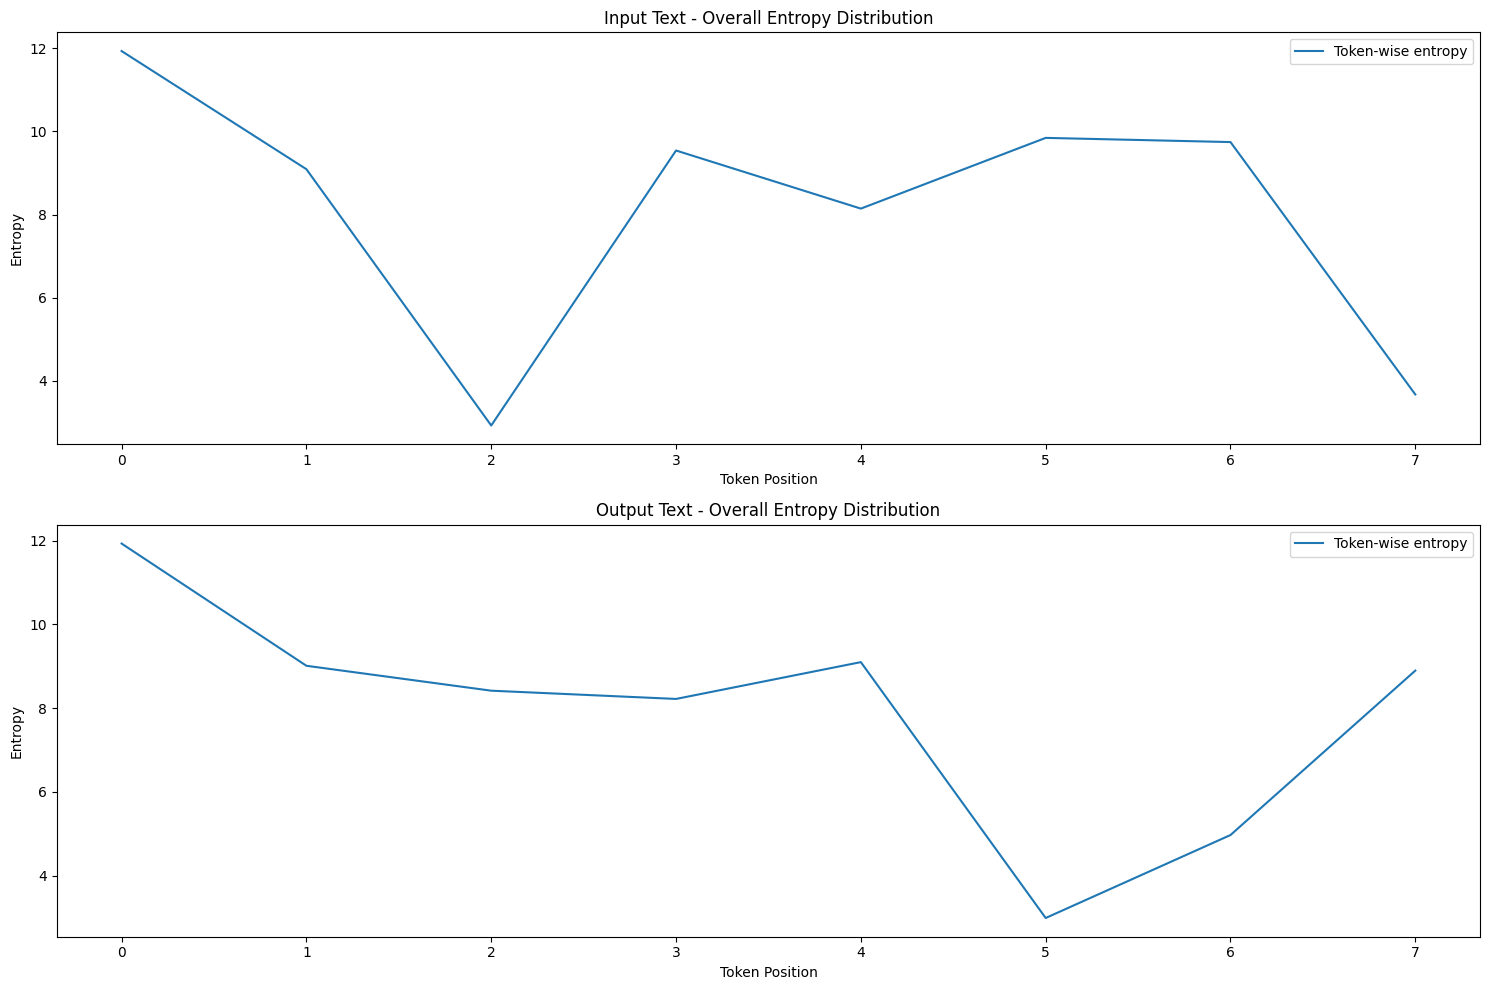

Input Text Statistics:
Mean entropy: 8.1117
Max entropy: 11.9294
Min entropy: 2.9305
Std entropy: 2.9526

Output Text Statistics:
Mean entropy: 7.9402
Max entropy: 11.9294
Min entropy: 2.9868
Std entropy: 2.5735


In [18]:

def calculate_token_entropies(model, tokenizer, text, device='cuda'):
    """Calculate entropy for each token in the text."""
    # Tokenize input
    inputs = tokenizer(text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    
    # Get model outputs
    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits # shpe: (1, seq_len, vocab_size)
    
    # Calculate probabilities and entropies
    probs = torch.softmax(logits[0], dim=-1)
    token_entropies = []
    
    for i in range(len(input_ids[0])):
        token_prob = probs[i].cpu().numpy()
        token_entropy = entropy(token_prob)
        token_entropies.append(token_entropy)
    
    # Calculate the entropy for uniform distribution
    uniform_entropy = np.log(len(tokenizer.vocab))
    
    return [uniform_entropy] + token_entropies, tokenizer.convert_ids_to_tokens(input_ids[0]) + ['next_token']


def plot_token_entropies(input_text, output_text, model_name, tokens_per_plot=50):
    """Plot entropy distributions for input and output text with multiple figures for long sequences."""
    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name,device_map='auto')
    
    # Calculate entropies for input and output
    input_entropies, input_tokens = calculate_token_entropies(model, tokenizer, input_text)
    output_entropies, output_tokens = calculate_token_entropies(model, tokenizer, output_text)
    
    def create_subplot_figures(tokens, entropies, prefix, tokens_per_plot=50):
        """Create multiple figures for long sequences"""
        num_tokens = len(tokens)
        num_plots = (num_tokens + tokens_per_plot - 1) // tokens_per_plot  # Ceiling division
        
        for plot_idx in range(num_plots):
            start_idx = plot_idx * tokens_per_plot
            end_idx = min(start_idx + tokens_per_plot, num_tokens)
            
            plt.figure(figsize=(15, 5))
            
            # Plot token entropies for this segment
            sns.barplot(x=range(end_idx - start_idx), 
                       y=entropies[start_idx:end_idx])
            
            # Create labels showing token transitions
            x_labels = [f"{tokens[i]} → {tokens[i+1]}" if i < len(tokens)-1 
                       else tokens[i] for i in range(start_idx, end_idx)]
            
            plt.title(f"{prefix} Token Entropies (Part {plot_idx + 1}/{num_plots})")
            plt.xticks(range(end_idx - start_idx), x_labels, rotation=45, ha='right')
            plt.ylabel("Entropy")
            plt.xlabel(f"Tokens {start_idx+1}-{end_idx} of {num_tokens}")
            
            # Add mean entropy line
            mean_entropy = np.mean(entropies[start_idx:end_idx])
            plt.axhline(y=mean_entropy, color='r', linestyle='--', 
                       label=f'Mean Entropy: {mean_entropy:.2f}')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(f'{prefix.lower()}_entropies_part_{plot_idx+1}.pdf')
            plt.close()
    
    # Create plots for input text
    create_subplot_figures(input_tokens, input_entropies, "Input", tokens_per_plot)
    
    # Create plots for output text
    create_subplot_figures(output_tokens, output_entropies, "Output", tokens_per_plot)
    
    # Create overview plots showing entropy distribution
    plt.figure(figsize=(15, 10))
    
    # Input text overview
    plt.subplot(2, 1, 1)
    plt.plot(input_entropies, label='Token-wise entropy')
    plt.title("Input Text - Overall Entropy Distribution")
    plt.xlabel("Token Position")
    plt.ylabel("Entropy")
    plt.legend()
    
    # Output text overview
    plt.subplot(2, 1, 2)
    plt.plot(output_entropies, label='Token-wise entropy')
    plt.title("Output Text - Overall Entropy Distribution")
    plt.xlabel("Token Position")
    plt.ylabel("Entropy")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    # plt.savefig('entropy_overview.pdf')
    plt.close()
    
    return {
        'input_entropies': input_entropies,
        'output_entropies': output_entropies,
        'input_tokens': input_tokens,
        'output_tokens': output_tokens
    }


def analyze_entropy_statistics(results):
    """Analyze and print entropy statistics."""
    print("Input Text Statistics:")
    print(f"Mean entropy: {np.mean(results['input_entropies']):.4f}")
    print(f"Max entropy: {np.max(results['input_entropies']):.4f}")
    print(f"Min entropy: {np.min(results['input_entropies']):.4f}")
    print(f"Std entropy: {np.std(results['input_entropies']):.4f}")
    print("\nOutput Text Statistics:")
    print(f"Mean entropy: {np.mean(results['output_entropies']):.4f}")
    print(f"Max entropy: {np.max(results['output_entropies']):.4f}")
    print(f"Min entropy: {np.min(results['output_entropies']):.4f}")
    print(f"Std entropy: {np.std(results['output_entropies']):.4f}")

# Example usage
if __name__ == "__main__":
    # Example question and answer
    input_text = "What is the capital of France?"
    output_text = "The capital of France is Paris."
    # Model name
    model_name = "Qwen/Qwen2.5-Math-7B-Instruct"
    # Run analysis
    results = plot_token_entropies(input_text, output_text, model_name=model_name)
    
    # Print statistics
    analyze_entropy_statistics(results)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


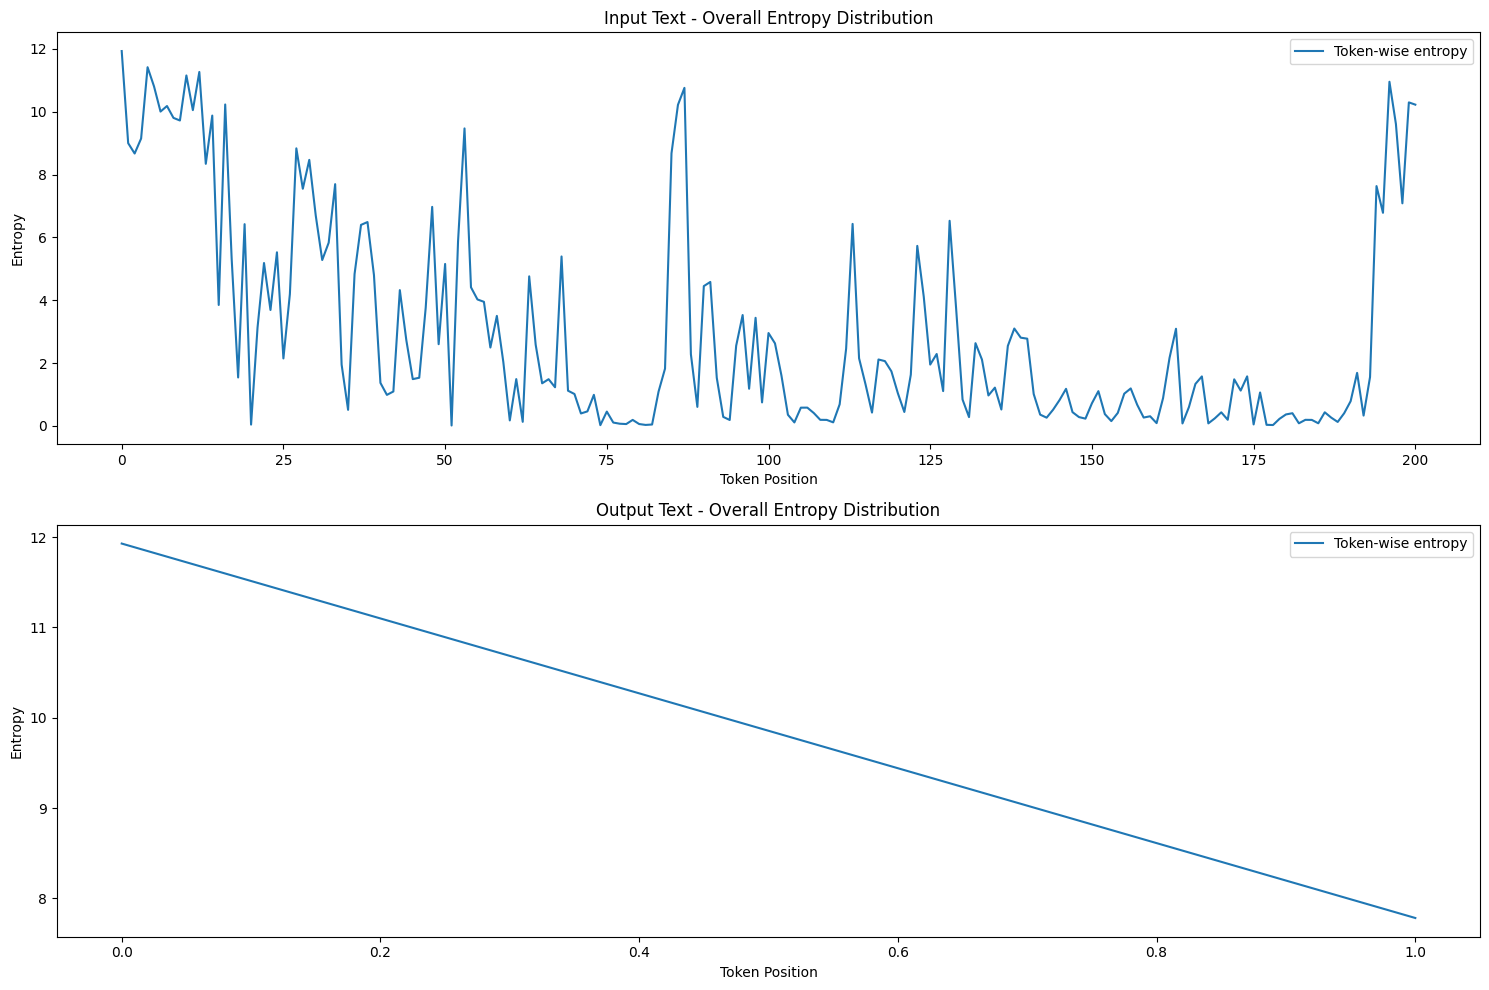

Input Text Statistics:
Mean entropy: 2.9951
Max entropy: 11.9294
Min entropy: 0.0135
Std entropy: 3.3034

Output Text Statistics:
Mean entropy: 9.8559
Max entropy: 11.9294
Min entropy: 7.7823
Std entropy: 2.0735


In [19]:

query = r"""  Here is the problem and the existing steps:  

    Problem: How many positive whole-number divisors does 196 have?
    Existing Steps:
    Step 1: Factorize 196 into its prime factors to determine its divisors. To find the number of positive whole-number divisors of 196, we first need to factorize 196 into its prime factors.  ##
    Step 2: The prime factorization of 196 is $2^2 \cdot 7^2$.
    Step 3: Understand the prime factorization of 196 The prime factorization of 196 is given as $2^2 \cdot 7^2$. This tells us that the number 196 has two distinct prime factors, 2 and 7, with 2 raised to the power of 2 and 7 raised to the power of 2.  ##

    Output:"""
# Model name
model_name = "Qwen/Qwen2.5-Math-7B-Instruct"
# Run analysis
results = plot_token_entropies(query, output_text='a', model_name=model_name)

# Print statistics
analyze_entropy_statistics(results)